# From Earth’s surface to lunar orbit — corrected 2D simulation

This extends the corrected Earth–Moon transfer to **start on the ground**. It models a two-stage, finite-thrust ascent with changing mass, atmospheric drag, stage separation, a finite translunar injection (TLI), a coast under Earth and Moon gravity, and a finite lunar orbit insertion (LOI). The Moon’s position is evaluated at each integration time. All dynamics use metres, seconds, and kilograms; plot labels convert to km.

**Scope:** This is an illustrative vehicle and guidance program, not a validated Falcon 9 mission design. It assumes equatorial prograde launch, constant thrust and specific impulse within each stage, exponential co-rotating atmosphere, circular coplanar lunar motion, and ideal steering. The parameters are explicitly shown below. The numerical solves target a 200 km Earth parking orbit and a 100 km circular lunar orbit.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares, brentq

G = 6.67430e-11
g0 = 9.80665
Me, Mm = 5.97219e24, 7.34767309e22
mu_e, mu_m = G*Me, G*Mm
Re, Rm = 6.3781e6, 1.738e6
Lm = 3.844e8
P_moon = 27.321661*86400
omega_m = 2*np.pi/P_moon
omega_e = 7.2921159e-5
rho0, scale_height, CdA = 1.225, 8500.0, 4.0  # kg/m³, m, m²
parking_altitude, lunar_altitude = 200e3, 100e3

# Illustrative two-stage launcher; service craft mass is included in the payload.
T1, Isp1, prop1, dry1 = 7.6e6, 300.0, 400e3, 30e3
T2, Isp2, prop2, dry2 = 981e3, 348.0, 110e3, 5e3
service_wet, service_prop = 5e3, 2e3
T_loi, Isp_loi = 20e3, 320.0
m_launch = prop1 + dry1 + prop2 + dry2 + service_wet
burn1 = prop1*Isp1*g0/T1
max_burn2 = prop2*Isp2*g0/T2
print(f'Liftoff mass {m_launch/1000:.1f} t; stage 1 burn {burn1:.1f} s; stage 2 capacity {max_burn2:.1f} s')


Liftoff mass 550.0 t; stage 1 burn 154.8 s; stage 2 capacity 382.7 s


## Powered ascent

At the surface, the spacecraft already has the equator’s eastward rotation speed. Gravity always points toward Earth. Drag opposes velocity relative to the co-rotating atmosphere. Stage mass falls at $\dot m=-T/(I_{sp}g_0)$. A smooth pitch program steers the thrust from vertical toward prograde. Three guidance values are solved so the stage-2 cutoff reaches 200 km altitude with zero radial speed and circular tangential speed.

In [2]:
def orbit_components(state):
    r, v = state[:2], state[2:4]
    radius = np.linalg.norm(r)
    radial = np.dot(r, v)/radius
    tangential = (r[0]*v[1] - r[1]*v[0])/radius
    return radius, radial, tangential


def ascent(params, details=False):
    pitch1_deg, pitch2_deg, burn2 = params
    pitch1, pitch2 = np.deg2rad([pitch1_deg, pitch2_deg])
    def pitch(t):
        if t < 10: return np.pi/2
        if t < burn1:
            return np.pi/2 + (pitch1-np.pi/2)*(t-10)/(burn1-10)
        return pitch1 + (pitch2-pitch1)*(t-burn1)/burn2
    def derivative(t, state, stage):
        r, v, mass = state[:2], state[2:4], state[4]
        radius = np.linalg.norm(r)
        upward = r/radius
        east = np.array([-upward[1], upward[0]])
        direction = np.sin(pitch(t))*upward + np.cos(pitch(t))*east
        thrust, isp = (T1, Isp1) if stage == 1 else (T2, Isp2)
        air_velocity = v - omega_e*np.array([-r[1], r[0]])
        altitude = radius-Re
        density = rho0*np.exp(-max(altitude,0)/scale_height)
        drag = -0.5*CdA*density*np.linalg.norm(air_velocity)*air_velocity/mass
        acceleration = -mu_e*r/radius**3 + thrust*direction/mass + drag
        return np.r_[v, acceleration, -thrust/(isp*g0)]
    initial = np.array([Re, 0, 0, omega_e*Re, m_launch], dtype=float)
    first = solve_ivp(lambda t,y: derivative(t,y,1), (0,burn1), initial,
                      rtol=1e-8, atol=1e-5, max_step=2, dense_output=details)
    if not first.success: raise RuntimeError(first.message)
    after_separation = first.y[:,-1].copy()
    after_separation[4] -= dry1
    second = solve_ivp(lambda t,y: derivative(t,y,2), (burn1,burn1+burn2),
                       after_separation, rtol=1e-8, atol=1e-5,
                       max_step=2, dense_output=details)
    if not second.success: raise RuntimeError(second.message)
    endpoint = second.y[:,-1]
    radius, radial, tangential = orbit_components(endpoint)
    residual = np.array([(radius-Re-parking_altitude)/1e5,
                         radial/100,
                         (tangential-np.sqrt(mu_e/radius))/100])
    return (first, second, endpoint, residual) if details else residual

ascent_fit = least_squares(ascent, [16.5,3.0,323],
                           bounds=([0,-45,100],[80,50,max_burn2]),
                           xtol=1e-10, ftol=1e-10, gtol=1e-10)
assert ascent_fit.success and np.linalg.norm(ascent_fit.fun)<1e-5
stage1, stage2, parking_state, _ = ascent(ascent_fit.x, details=True)
t_parking = burn1 + ascent_fit.x[2]
r_parking, vr_parking, vt_parking = orbit_components(parking_state)
assert parking_state[4] > dry2 + service_wet
assert min(np.linalg.norm(stage1.y[:2],axis=0).min(),
           np.linalg.norm(stage2.y[:2],axis=0).min()) >= Re-1
print(f'Parking orbit: altitude {(r_parking-Re)/1000:.3f} km, radial speed {vr_parking:.5f} m/s')
print(f'Tangential speed {vt_parking/1000:.3f} km/s; stage-2 propellant left {((parking_state[4]-dry2-service_wet)/1000):.2f} t')
print(f'Guidance: stage-1 end pitch {ascent_fit.x[0]:.2f}°, stage-2 end pitch {ascent_fit.x[1]:.2f}°')


Parking orbit: altitude 200.000 km, radial speed -0.00000 m/s
Tangential speed 7.784 km/s; stage-2 propellant left 17.15 t
Guidance: stage-1 end pitch 16.54°, stage-2 end pitch 3.03°


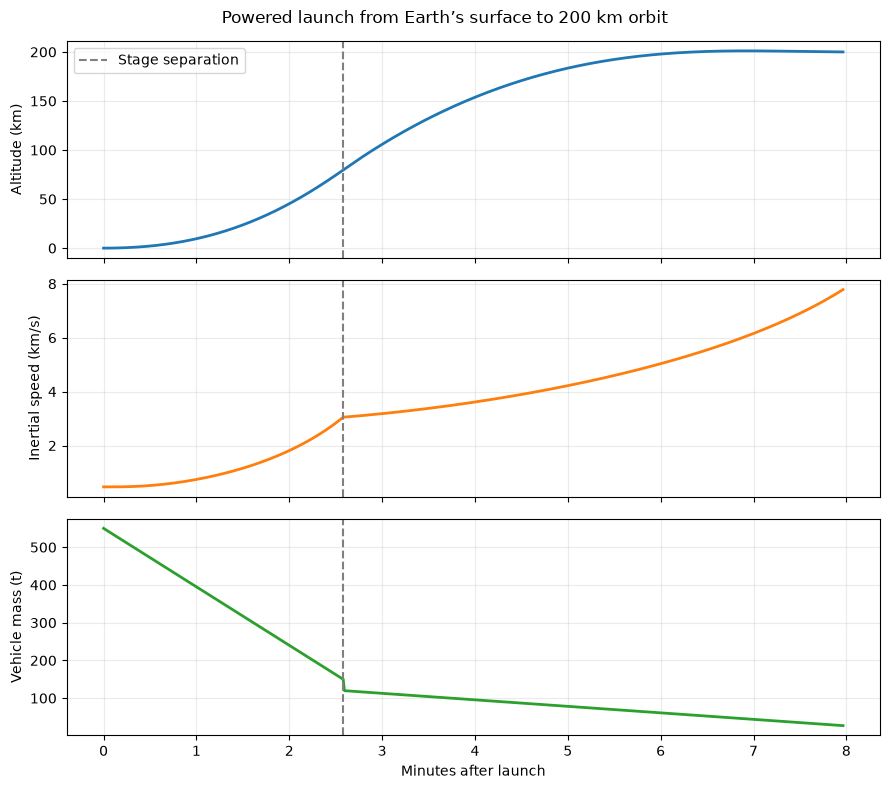

In [3]:
t_ascent = np.r_[np.linspace(0,burn1,260), np.linspace(burn1,t_parking,400)[1:]]
y_ascent = np.column_stack([stage1.sol(t) if t<=burn1 else stage2.sol(t) for t in t_ascent])
altitude_ascent = (np.linalg.norm(y_ascent[:2],axis=0)-Re)/1000
speed_ascent = np.linalg.norm(y_ascent[2:4],axis=0)/1000
mass_ascent = y_ascent[4]/1000
fig, axes = plt.subplots(3,1,figsize=(9,8),sharex=True)
for ax,values,label,color in zip(axes,[altitude_ascent,speed_ascent,mass_ascent],
                                 ['Altitude (km)','Inertial speed (km/s)','Vehicle mass (t)'],
                                 ['tab:blue','tab:orange','tab:green']):
    ax.plot(t_ascent/60,values,color=color,lw=2)
    ax.axvline(burn1/60,color='gray',ls='--',label='Stage separation')
    ax.set_ylabel(label); ax.grid(alpha=.25)
axes[0].legend(); axes[-1].set_xlabel('Minutes after launch')
fig.suptitle('Powered launch from Earth’s surface to 200 km orbit')
fig.tight_layout(); plt.show()


## Finite translunar injection

Stage 2 restarts immediately after reaching parking orbit and thrusts along the local prograde tangent. Burn duration is solved so the resulting Earth-centered two-body apogee is near lunar distance. The remaining stage-2 hardware and propellant are then jettisoned; the 5 t service craft continues the coast.

In [4]:
def tli_derivative(t, state):
    r, v, mass = state[:2], state[2:4], state[4]
    radius = np.linalg.norm(r)
    tangent = np.array([-r[1],r[0]])/radius
    acceleration = -mu_e*r/radius**3 + T2*tangent/mass
    return np.r_[v,acceleration,-T2/(Isp2*g0)]

def tli_trajectory(duration, details=False):
    solution = solve_ivp(tli_derivative,(t_parking,t_parking+duration),parking_state,
                         rtol=1e-9,atol=1e-5,max_step=1,dense_output=details)
    if not solution.success: raise RuntimeError(solution.message)
    state = solution.y[:,-1]
    r,v = state[:2],state[2:4]
    energy = np.dot(v,v)/2 - mu_e/np.linalg.norm(r)
    if energy >= 0: raise ValueError('TLI burn escaped Earth; apogee is undefined')
    semi_major = -mu_e/(2*energy)
    apogee = 2*semi_major-np.linalg.norm(r)
    return (solution,state,apogee) if details else apogee

tli_duration = brentq(lambda duration:tli_trajectory(duration)-Lm,56,57.5)
tli_burn,tli_state,apogee = tli_trajectory(tli_duration,details=True)
t_tli = t_parking+tli_duration
stage2_prop_remaining = tli_state[4]-dry2-service_wet
assert stage2_prop_remaining>0
print(f'TLI burn: {tli_duration:.2f} s; ideal Earth-only apogee {apogee/1000:.0f} km')
print(f'Stage-2 propellant remaining at separation: {stage2_prop_remaining:.0f} kg')


TLI burn: 56.72 s; ideal Earth-only apogee 384400 km
Stage-2 propellant remaining at separation: 845 kg


## Coast and lunar targeting

The Moon follows a circular orbit. Earth and lunar gravity are integrated throughout the coast, including the indirect Earth-centered term. Lunar phase is solved together with finite LOI timing and duration to target a 100 km circular orbit. There is **no straight-line interpolation** of the spacecraft trajectory.

In [5]:
def moon_position(t,phase):
    angle=phase+omega_m*t
    return Lm*np.array([np.cos(angle),np.sin(angle)])

def moon_velocity(t,phase):
    moon=moon_position(t,phase)
    return omega_m*np.array([-moon[1],moon[0]])

def coast_derivative(t,state,phase):
    r,v=state[:2],state[2:4]
    moon=moon_position(t,phase)
    delta=moon-r
    acceleration=(-mu_e*r/np.linalg.norm(r)**3
                  +mu_m*(delta/np.linalg.norm(delta)**3
                          -moon/np.linalg.norm(moon)**3))
    return np.r_[v,acceleration]

def encounter(phase):
    def closest_event(t,state,_phase):
        relative_r=state[:2]-moon_position(t,phase)
        relative_v=state[2:4]-moon_velocity(t,phase)
        return np.dot(relative_r,relative_v)
    closest_event.direction=1
    closest_event.terminal=False
    solution=solve_ivp(coast_derivative,(t_tli,t_tli+8*86400),tli_state[:4],
                       args=(phase,),events=closest_event,rtol=1e-8,atol=1e-4,
                       max_step=1800,dense_output=True)
    if not solution.success:raise RuntimeError(solution.message)
    approaches=[(np.linalg.norm(state[:2]-moon_position(t,phase)),t,state)
                for t,state in zip(solution.t_events[0],solution.y_events[0])
                if t>2*86400]
    if not approaches:raise RuntimeError('No lunar encounter after day 2')
    return min(approaches,key=lambda item:item[0]),solution

# An unpowered 100 km perilune gives a good initial guess for the finite LOI solve.
phase_guess=brentq(lambda phase:encounter(phase)[0][0]-(Rm+lunar_altitude),2.1,2.2)
print(f'Initial lunar phase guess: {np.degrees(phase_guess):.2f}°')


Initial lunar phase guess: 125.42°


## Finite lunar orbit insertion

The service craft has 2 t of its 5 t wet mass allocated to LOI propellant. Its 20 kN engine points opposite the Moon-relative tangential motion. The solver varies initial lunar phase, burn start relative to the unpowered perilune, and burn duration. Its three endpoint conditions are 100 km altitude, zero radial speed, and circular tangential speed.

In [6]:
def lunar_burn(trial,details=False):
    phase,start_offset,duration=trial
    (_,unpowered_perilune,_),coast=encounter(phase)
    start=unpowered_perilune+start_offset
    initial=np.r_[coast.sol(start),service_wet]
    def derivative(t,state,_phase):
        base=coast_derivative(t,state[:4],phase)
        relative_r=state[:2]-moon_position(t,phase)
        relative_r/=np.linalg.norm(relative_r)
        tangent=np.array([-relative_r[1],relative_r[0]])
        relative_v=state[2:4]-moon_velocity(t,phase)
        sense=np.sign(relative_r[0]*relative_v[1]-relative_r[1]*relative_v[0])
        base[2:4]-=sense*T_loi*tangent/state[4]
        return np.r_[base,-T_loi/(Isp_loi*g0)]
    burn=solve_ivp(derivative,(start,start+duration),initial,args=(phase,),
                   rtol=1e-9,atol=1e-5,max_step=2,dense_output=details)
    if not burn.success:raise RuntimeError(burn.message)
    endpoint=burn.y[:,-1]
    t_end=start+duration
    r=endpoint[:2]-moon_position(t_end,phase)
    v=endpoint[2:4]-moon_velocity(t_end,phase)
    radius=np.linalg.norm(r)
    radial=np.dot(r,v)/radius
    tangential=abs(r[0]*v[1]-r[1]*v[0])/radius
    circular=np.sqrt(mu_m/radius)
    residual=np.array([(radius-Rm-lunar_altitude)/1e4,
                       radial/100,(tangential-circular)/100])
    return (coast,burn,start,endpoint,residual) if details else residual

loi_fit=least_squares(lunar_burn,[phase_guess,-90,180],
                      bounds=([2.1,-600,50],[2.2,100,290]),max_nfev=40,
                      xtol=1e-9,ftol=1e-9,gtol=1e-9)
assert loi_fit.success and np.linalg.norm(loi_fit.fun)<1e-5
coast,loi_burn,t_loi_start,loi_endpoint,_=lunar_burn(loi_fit.x,details=True)
phase,_,loi_duration=loi_fit.x
t_loi_end=t_loi_start+loi_duration
assert loi_endpoint[4]>=service_wet-service_prop
moon_end=moon_position(t_loi_end,phase)
relative_end=loi_endpoint[:2]-moon_end
relative_velocity=loi_endpoint[2:4]-moon_velocity(t_loi_end,phase)
print(f'LOI starts on day {t_loi_start/86400:.3f} and burns for {loi_duration:.1f} s')
print(f'Circular-orbit altitude {(np.linalg.norm(relative_end)-Rm)/1000:.3f} km')
print(f'LOI propellant used {(service_wet-loi_endpoint[4]):.0f} of {service_prop:.0f} kg')


LOI starts on day 5.294 and burns for 180.1 s
Circular-orbit altitude 100.000 km
LOI propellant used 1148 of 2000 kg


## Verify the captured orbit and plot the full mission

In [7]:
lunar_period=2*np.pi*np.sqrt((Rm+lunar_altitude)**3/mu_m)
post=solve_ivp(coast_derivative,(t_loi_end,t_loi_end+2*lunar_period),
               loi_endpoint[:4],args=(phase,),rtol=1e-10,atol=1e-6,
               max_step=60,dense_output=True)
assert post.success
post_times=np.linspace(t_loi_end,t_loi_end+2*lunar_period,1000)
post_states=post.sol(post_times)
post_moons=np.array([moon_position(t,phase) for t in post_times]).T
post_altitudes=np.linalg.norm(post_states[:2]-post_moons,axis=0)-Rm
assert np.min(post_altitudes)>0
assert np.max(np.abs(post_altitudes-lunar_altitude))<2e3
print(f'Altitude over two lunar revolutions: {post_altitudes.min()/1000:.2f}–{post_altitudes.max()/1000:.2f} km')


Altitude over two lunar revolutions: 99.90–100.14 km


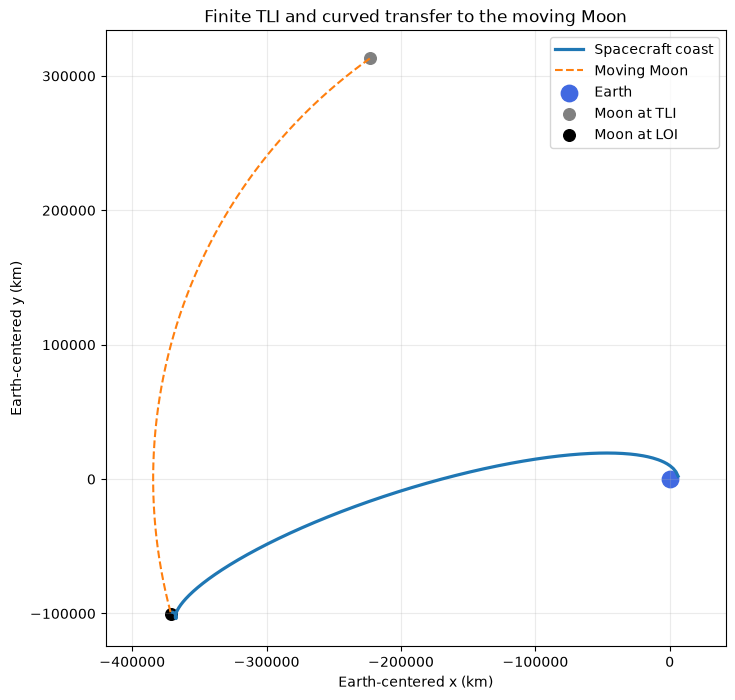

In [8]:
coast_times=np.linspace(t_tli,t_loi_start,1400)
coast_states=coast.sol(coast_times)
moon_track=np.array([moon_position(t,phase) for t in coast_times]).T
fig,ax=plt.subplots(figsize=(8,8))
ax.plot(coast_states[0]/1000,coast_states[1]/1000,lw=2.3,label='Spacecraft coast')
ax.plot(moon_track[0]/1000,moon_track[1]/1000,'--',lw=1.5,label='Moving Moon')
ax.scatter([0],[0],s=140,color='royalblue',label='Earth')
ax.scatter([moon_track[0,0]/1000],[moon_track[1,0]/1000],s=70,color='gray',label='Moon at TLI')
ax.scatter([moon_track[0,-1]/1000],[moon_track[1,-1]/1000],s=70,color='black',label='Moon at LOI')
ax.set(xlabel='Earth-centered x (km)',ylabel='Earth-centered y (km)',
       title='Finite TLI and curved transfer to the moving Moon')
ax.axis('equal');ax.grid(alpha=.25);ax.legend();plt.show()


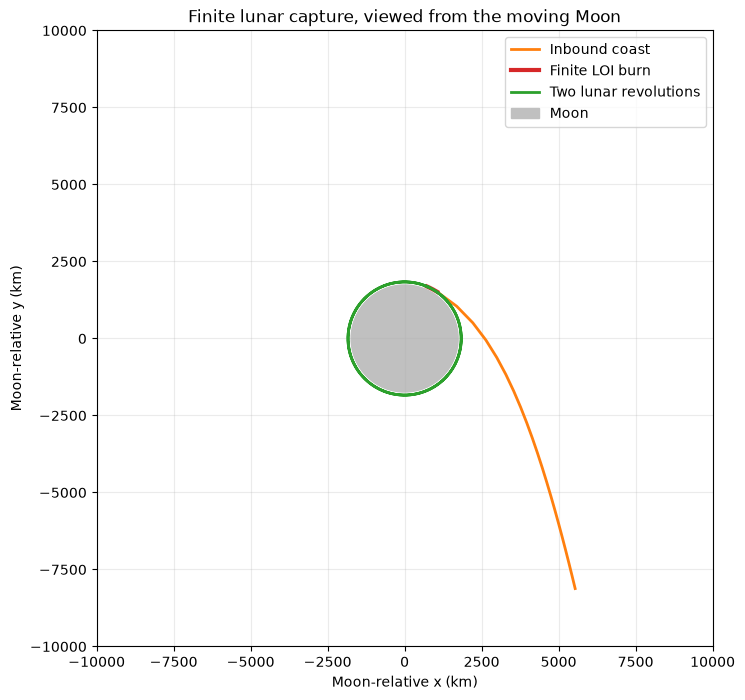

In [9]:
near=np.linalg.norm(coast_states[:2]-moon_track,axis=0)<10000e3
relative_coast=coast_states[:2]-moon_track
burn_times=np.linspace(t_loi_start,t_loi_end,160)
burn_states=loi_burn.sol(burn_times)
burn_moons=np.array([moon_position(t,phase) for t in burn_times]).T
relative_burn=burn_states[:2]-burn_moons
relative_post=post_states[:2]-post_moons
fig,ax=plt.subplots(figsize=(8,8))
ax.plot(relative_coast[0,near]/1000,relative_coast[1,near]/1000,
        color='tab:orange',lw=2,label='Inbound coast')
ax.plot(relative_burn[0]/1000,relative_burn[1]/1000,
        color='tab:red',lw=3,label='Finite LOI burn')
ax.plot(relative_post[0]/1000,relative_post[1]/1000,
        color='tab:green',lw=2,label='Two lunar revolutions')
ax.add_patch(plt.Circle((0,0),Rm/1000,color='silver',label='Moon'))
ax.set(xlim=(-10000,10000),ylim=(-10000,10000),
       xlabel='Moon-relative x (km)',ylabel='Moon-relative y (km)',
       title='Finite lunar capture, viewed from the moving Moon')
ax.set_aspect('equal',adjustable='box');ax.grid(alpha=.25);ax.legend();plt.show()


### Interpretation and limits

This run begins at Earth’s surface and uses finite engine burns for ascent, TLI, and LOI. It numerically reaches a 200 km parking orbit, a 100 km lunar orbit, and remains above the lunar surface for two revolutions. It still omits launch-site latitude, 3D inclinations, detailed engine throttle limits, heating, aerodynamic stability, a finite stage-separation and ignition delay, actual hardware constraints, and long-term orbit maintenance. The solver finds one feasible trajectory under these stated assumptions; it does not prove global fuel optimality.